In [3]:
# обязательно запустить, чтобы загружать модули через model.
import sys
from pathlib import Path
if str(Path().resolve().parent) not in sys.path:
    sys.path.insert(0, str(Path().resolve().parent))


# ИЗМЕНИТЬ ДЛЯ ИСПОЛЬЗОВАНИЯ
PROJECT_PATH =  "D:/model_descriptor/ML_MAGA/project/"
GENERAL_PATH = PROJECT_PATH + "coco_yolo/"
TEST_PATH =    PROJECT_PATH + "dataset/test/"
WEIGHTS_PATH = PROJECT_PATH + "model/runs/weights/"

# Анализ

In [2]:
import os
import glob
from collections import defaultdict
import numpy as np

[{'id': 0, 'name': 'football-objects', 'supercategory': 'none'},
 {'id': 1, 'name': 'ball', 'supercategory': 'football-objects'},
 {'id': 2, 'name': 'coach', 'supercategory': 'football-objects'},
 {'id': 3, 'name': 'goalkeeper', 'supercategory': 'football-objects'},
 {'id': 4, 'name': 'player', 'supercategory': 'football-objects'},
 {'id': 5, 'name': 'referee', 'supercategory': 'football-objects'}]

labels = {1: 'ball', 2: 'coach', 3: 'goalkeeper', 4: 'player', 5: 'referee'}

def process_labels_folder(labels_dir):
    list_w, list_h = [], []
    class_total_area = defaultdict(float)
    class_total_w = defaultdict(float)
    class_total_h = defaultdict(float)
    class_count = defaultdict(int)

    # Поиск всех .txt файлов в папке labels
    label_files = glob.glob(os.path.join(labels_dir, "*.txt"))

    for file_path in label_files:
        with open(file_path, 'r') as f:
            lines = f.readlines()
        for line in lines:
            line = line.strip()
            if not line:
                continue
            parts = line.split()
            if len(parts) < 5:
                continue

            try:
                cls = int(parts[0])
                w = float(parts[3])
                h = float(parts[4])
                area = w * h

                class_total_area[cls] += area
                class_total_w[cls] += w
                class_total_h[cls] += h
                list_w.append(w)
                list_h.append(h)
                class_count[cls] += 1

            except (ValueError, IndexError):
                print(f"Warning: некорректная строка в {file_path}: {line}")
                continue

    print("Статистика ширины и высота боксов по классам:")
    for cls in sorted(class_total_area.keys()):
        avg_area = class_total_area[cls] / class_count[cls]
        avg_w = class_total_w[cls] / class_count[cls]
        avg_h = class_total_h[cls] / class_count[cls]
        print(f"Класс {labels[cls]:<11} avg_w = {avg_w:.4f}, avg_h = {avg_h:.4f}, (всего боксов: {class_count[cls]})")

    np_list_w = np.array(list_w)
    np_list_h = np.array(list_h)

    print("\nОбщая статистика ширины и высота боксов:")
    print(f"min_w = {np_list_w.min()}, min_h = {np_list_h.min()}")
    print(f"max_w = {np_list_w.max()}, max_h = {np_list_h.max()}")
    print(f"quantile_75 = {np.quantile(np_list_h, 0.75):.4f}")
    print(f"quantile_85 = {np.quantile(np_list_h, 0.85):.4f}")
    print(f"quantile_95 = {np.quantile(np_list_h, 0.95):.4f}")
    print(f"quantile_99 = {np.quantile(np_list_h, 0.99):.4f}")

labels_dir = "D:\model_descriptor\ML_MAGA\project\coco_yolo\labels\\train"  # ← измените, если папка называется иначе или лежит в другом месте
if not os.path.isdir(labels_dir):
    print(f"Ошибка: папка '{labels_dir}' не найдена.")
    exit(1)
process_labels_folder(labels_dir)

Статистика ширины и высота боксов по классам:
Класс ball        avg_w = 0.0086, avg_h = 0.0156, (всего боксов: 591)
Класс coach       avg_w = 0.0245, avg_h = 0.0834, (всего боксов: 164)
Класс goalkeeper  avg_w = 0.0236, avg_h = 0.0785, (всего боксов: 219)
Класс player      avg_w = 0.0231, avg_h = 0.0850, (всего боксов: 9901)
Класс referee     avg_w = 0.0218, avg_h = 0.0766, (всего боксов: 1088)

Общая статистика ширины и высота боксов:
min_w = 0.00038, min_h = 0.000556
max_w = 0.087818, max_h = 0.351852
quantile_75 = 0.0955
quantile_85 = 0.1033
quantile_95 = 0.1188
quantile_99 = 0.1415


# Обучение

In [2]:
import os
import torch
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import albumentations as A
from albumentations.pytorch import ToTensorV2
import random

def load_yolo_annotations(img_path, label_path):
    """
    Загружает изображение и аннотации в формате YOLO.
    Возвращает: image [3, H, W], targets [M, 5] = [cls, x, y, w, h] (нормализованные)
    !!!ВОЗВРАЩАЕТ классы с индексами от 0, даже если на вход идут начиная с 1!!!
    """
    # Загрузка изображения
    img = Image.open(img_path).convert('RGB')
    w, h = img.size

    # Загрузка аннотаций
    if not os.path.exists(label_path) or os.path.getsize(label_path) == 0:
        targets = torch.empty(0, 5)
    else:
        boxes = []
        with open(label_path) as f:
            for line in f:
                parts = list(map(float, line.strip().split()))
                if len(parts) < 5: continue
                cls_id, x, y, w, h = parts[:5]
                boxes.append([cls_id-1, x, y, w, h])
        targets = torch.tensor(boxes) if boxes else torch.empty(0, 5)

        if (targets[:, 0].min == 1):
            targets[:, 0] -= 1

    return img, targets

d:\model_descriptor\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import os
import numpy as np
from PIL import Image
import cv2 

def build_rare_patches(img_paths, label_paths, imgsz, output_dir="patches", augment_classes={0, 1, 2, 4}):
    os.makedirs(output_dir, exist_ok=True)
    patches = []  # [(patch, mask, cls_id), ...]
    
    for idx, (img_path, label_path) in enumerate(zip(img_paths, label_paths)):
        img_pil, targets = load_yolo_annotations(img_path, label_path)
        img = np.array(img_pil)  # [H_orig, W_orig, 3], uint8
        H_orig, W_orig = img.shape[:2]

        img_resized = cv2.resize(img, (imgsz, imgsz), interpolation=cv2.INTER_AREA)
        # img_resized = np.array(img_pil.resize((imgsz, imgsz), Image.LANCZOS))
        
        for target in targets:
            if target.numel() == 0:
                continue
            cls_id = int(target[0])
            if cls_id not in augment_classes:
                continue

            x, y, w, h = target[1:].tolist()

            cx, cy = x * imgsz, y * imgsz
            bw, bh = w * imgsz, h * imgsz
            x1_full = int(cx - bw / 2)
            y1_full = int(cy - bh / 2)
            x2_full = int(cx + bw / 2)
            y2_full = int(cy + bh / 2)

            x1_full = max(0, x1_full)
            y1_full = max(0, y1_full)
            x2_full = min(imgsz, x2_full)
            y2_full = min(imgsz, y2_full)

            if x2_full <= x1_full or y2_full <= y1_full:
                continue

            pad_x = int(0.1 * bw)
            pad_y = int(0.1 * bh)
            x1_pat = max(0, x1_full - pad_x)
            y1_pat = max(0, y1_full - pad_y)
            x2_pat = min(imgsz, x2_full + pad_x)
            y2_pat = min(imgsz, y2_full + pad_y)

            patch = img_resized[y1_pat:y2_pat, x1_pat:x2_pat]  # [hp, wp, 3]
            if patch.size == 0 or patch.shape[0] == 0 or patch.shape[1] == 0:
                continue

            bbox_x1_in_pat = x1_full - x1_pat
            bbox_y1_in_pat = y1_full - y1_pat
            bbox_x2_in_pat = x2_full - x1_pat
            bbox_y2_in_pat = y2_full - y1_pat

            bbox_x1_in_pat = max(0, bbox_x1_in_pat)
            bbox_y1_in_pat = max(0, bbox_y1_in_pat)
            bbox_x2_in_pat = min(patch.shape[1], bbox_x2_in_pat)
            bbox_y2_in_pat = min(patch.shape[0], bbox_y2_in_pat)

            if bbox_x2_in_pat <= bbox_x1_in_pat or bbox_y2_in_pat <= bbox_y1_in_pat:
                continue

            mask = np.zeros(patch.shape[:2], dtype=bool)
            mask[bbox_y1_in_pat:bbox_y2_in_pat, bbox_x1_in_pat:bbox_x2_in_pat] = True

            # Сохраняем
            cls_name = {0: 'ball', 1: 'coach', 2: 'gk', 4: 'ref'}.get(cls_id, f'cls{cls_id}')
            path = os.path.join(output_dir, f"{cls_name}_{idx}_{len(patches)}.png")
            try:
                Image.fromarray(patch).save(path)
            except Exception as e:
                print(f"⚠️ Не удалось сохранить {path}: {e}")
                continue

            patches.append((patch, mask, cls_id))
    
    counts = {k: sum(1 for p in patches if p[2] == k) for k in augment_classes}
    print(f"Собрано {len(patches)} редких патчей: {counts}")
    return patches

In [ ]:
import os
import random
import numpy as np
import torch
from torch.utils.data import Dataset
from PIL import Image
import albumentations as A
from albumentations.pytorch import ToTensorV2

class YOLODataset(Dataset):
    def __init__(self, img_dir, label_dir, patches_dir, imgsz=640, augment=True):
        self.img_paths = sorted([
            os.path.join(img_dir, f) 
            for f in os.listdir(img_dir) 
            if f.endswith(('.jpg', '.png'))
        ])
        
        self.label_paths = [
            os.path.join(label_dir, os.path.basename(p).replace('.jpg', '.txt').replace('.png', '.txt'))
            for p in self.img_paths
        ]
        self.imgsz = imgsz
        self.augment = augment

        # Статистика для oversampling
        self.class_counts = {
            0: 739,   # ball
            1: 202,   # coach
            2: 281,   # goalkeeper
            3: 12261, # player
            4: 1321   # referee
        }
        self.augment_classes = {0}

        max_count = max(self.class_counts.values())
        self.oversample_factors = {
            cls_id: min(5, max_count // count)
            for cls_id, count in self.class_counts.items()
            if cls_id in self.augment_classes and count > 0
        }

        self._rare_patches = None
        if (augment):
            self._rare_patches = build_rare_patches(self.img_paths, self.label_paths, self.imgsz, patches_dir)

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img_path = self.img_paths[idx]
        label_path = self.label_paths[idx]
        
        img, targets = load_yolo_annotations(img_path, label_path)  # PIL, torch.Tensor [N, 5]
        
        # Проверка: есть ли редкие классы в этом изображении
        has_rare = False
        if targets.numel() > 0:
            cls_ids = targets[:, 0].int()
            has_rare = bool((cls_ids.unsqueeze(1) == torch.tensor(list(self.augment_classes))).any())

        # Решаем: делать ли oversampling?
        do_oversample = self.augment and has_rare and random.random() < 0.7
        
        if do_oversample:
            img, targets = self._augment_with_copy_paste(img, targets)
        elif self.augment:
            img, targets = self._basic_augment(img, targets)
        else:
            img, targets = self._resize_and_normalize(img, targets)
    
        return img, targets  # img: torch.Tensor [3, H, W], targets: torch.Tensor [M, 5]
    
    def _clamp_bbox_coords(self, bboxes):
        """Приводит bbox к [0, 1] с учётом YOLO-формата: [x, y, w, h]"""
        bboxes = np.array(bboxes, dtype=np.float32)
        if bboxes.size == 0:
            return bboxes
        
        # x, y ∈ [0, 1]
        bboxes[:, 0] = np.clip(bboxes[:, 0], 0.0, 1.0)
        bboxes[:, 1] = np.clip(bboxes[:, 1], 0.0, 1.0)
        
        # w, h ≥ 0 и таковы, что bbox не выходит за границы
        bboxes[:, 2] = np.clip(bboxes[:, 2], 0.0, 1.0)  # w
        bboxes[:, 3] = np.clip(bboxes[:, 3], 0.0, 1.0)  # h
        
        # Доп. защита: чтобы x ± w/2 ∈ [0,1]
        bboxes[:, 2] = np.minimum(bboxes[:, 2], 2 * np.minimum(bboxes[:, 0], 1 - bboxes[:, 0]))
        bboxes[:, 3] = np.minimum(bboxes[:, 3], 2 * np.minimum(bboxes[:, 1], 1 - bboxes[:, 1]))
    
        return bboxes

    def _basic_augment(self, img, targets):
        # Конвертируем targets в numpy для Albumentations
        # координаты остаются в формате YOLO
        if isinstance(targets, torch.Tensor):
            targets = targets.cpu().numpy()  # [N, 5]

        class_labels = targets[:, 0].astype(int).tolist() if len(targets) > 0 else []
        bboxes = targets[:, 1:].tolist() if len(targets) > 0 else []
        bboxes = self._clamp_bbox_coords(bboxes)

        transform = A.Compose([
            # A.Mosaic(p=0.2),
            A.HorizontalFlip(p=0.5),
            A.HueSaturationValue(hue_shift_limit=20, sat_shift_limit=30, val_shift_limit=20, p=0.5),
            A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
            A.Resize(height=self.imgsz, width=self.imgsz),
            # A.Normalize(mean=[0, 0, 0], std=[255, 255, 255]),
            ToTensorV2(),
        ], bbox_params=A.BboxParams(
            format='yolo',
            label_fields=['class_labels'],
            min_visibility=0.1,
            min_area=1.0
        ))

        transformed = transform(
            image=np.array(img),  # PIL → (H, W, 3), uint8, RGB
            bboxes=bboxes,
            class_labels=class_labels
        )

        # Восстановление targets как torch.Tensor
        if len(transformed['bboxes']) > 0:
            bboxes = torch.tensor(transformed['bboxes'], dtype=torch.float32)
            classes = torch.tensor(transformed['class_labels'], dtype=torch.float32).unsqueeze(1)
            targets = torch.cat([classes, bboxes], dim=1)  # [M, 5]
        else:
            targets = torch.empty(0, 5, dtype=torch.float32)

        img_tensor = transformed['image'] / 255.0  # [3, H, W], float32, [0,1]
        return img_tensor, targets

    def _resize_and_normalize(self, img, targets):
        # координаты остаются в формате YOLO
        """Без аугментаций — только resize + ToTensor + нормализация."""
        transform = A.Compose([
            A.Resize(height=self.imgsz, width=self.imgsz),
            # A.Normalize(mean=[0, 0, 0], std=[255, 255, 255]),
            ToTensorV2(),
        ], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

        if isinstance(targets, torch.Tensor):
            targets = targets.cpu().numpy()

        bboxes = targets[:, 1:].tolist() if len(targets) > 0 else []
        bboxes = self._clamp_bbox_coords(bboxes)
        class_labels = targets[:, 0].astype(int).tolist() if len(targets) > 0 else []

        transformed = transform(
            image=np.array(img),
            bboxes=bboxes,
            class_labels=class_labels
        )

        if len(transformed['bboxes']) > 0:
            bboxes = torch.tensor(transformed['bboxes'], dtype=torch.float32)
            classes = torch.tensor(transformed['class_labels'], dtype=torch.float32).unsqueeze(1)
            targets = torch.cat([classes, bboxes], dim=1)
        else:
            targets = torch.empty(0, 5, dtype=torch.float32)

        return transformed['image'] / 255.0, targets

    def _find_safe_position(self, img, bboxes, patch_shape):
        """
            Случайный поиск свободного места
            Возвращает абсолютные x и y или -1 -1 если не удалось найти место
        """
        H, W = img.shape[:2]
        ph, pw = patch_shape[:2]
        max_tries = 200
        for _ in range(max_tries):
            x = random.randint(0, max(0, W - pw))
            y = random.randint(0, max(0, H - ph))
            in_range_box = False
            intersection = False
            # Проверка пересечения с существующими bbox (грубая)
            cx, cy = x + pw / 2, y + ph / 2
            for bx, by, bw, bh in bboxes:
                # Денормализуем bbox
                bx *= W; by *= H; bw *= W; bh *= H
                if abs(cx - bx) < (bw + pw)/2 and abs(cy - by) < (bh + ph)/2:
                    intersection = True
                    break  # пересекается
                if by - bh / 2 < cy < by + bh / 2:
                    in_range_box = True
            if (not intersection and in_range_box):
                return x, y
        return -1, -1

    def _paste_with_mask(self, img, patch, mask, x, y):
        """Вставка с маской (patch и mask — np.ndarray)."""
        h, w = patch.shape[:2]
        # Границы
        x1, x2 = x, min(x + w, img.shape[1])
        y1, y2 = y, min(y + h, img.shape[0])
        pw, ph = x2 - x1, y2 - y1

        # Маска может быть меньше из-за выхода за границы
        mask_roi = mask[:ph, :pw]
        patch_roi = patch[:ph, :pw]
        img_roi = img[y1:y2, x1:x2]

        # Альфа-смешение (можно упростить до замены)
        img_roi[mask_roi] = patch_roi[mask_roi]
        return img

    def _augment_with_copy_paste(self, img, targets):
        # Сначала базовые аугментации → получим изображение в [3, H, W], float32, [0,1]
        img_tensor, targets = self._basic_augment(img, targets)  # torch.Tensor

        # Конвертируем в numpy для вставки
        np_img = (img_tensor.permute(1, 2, 0).numpy() * 255).astype(np.uint8)  # [H, W, 3], uint8
        targets_np = targets.cpu().numpy() if isinstance(targets, torch.Tensor) else targets

        bboxes = targets_np[:, 1:].copy() if len(targets_np) > 0 else np.empty((0, 4))
        classes = targets_np[:, 0].copy() if len(targets_np) > 0 else np.array([])

        for cls_id in self.augment_classes:
            n_paste = random.randint(1, self.oversample_factors.get(cls_id, 1))
            candidates = [p for p in self._rare_patches if p[2] == cls_id]
            if not candidates:
                continue
            for _ in range(n_paste):
                patch_img, patch_mask, _ = random.choice(candidates)
                x, y = self._find_safe_position(np_img, bboxes, patch_img.shape)
                if (x == -1 or y == -1):
                    continue
                np_img = self._paste_with_mask(np_img, patch_img, patch_mask, x, y)

                # Добавляем bbox в YOLO-формате (нормализованный)
                ph, pw = patch_img.shape[:2]
                cx = (x + pw / 2) / self.imgsz
                cy = (y + ph / 2) / self.imgsz
                bw = pw / self.imgsz
                bh = ph / self.imgsz

                bboxes = np.vstack([bboxes, [cx, cy, bw, bh]])
                classes = np.append(classes, cls_id)

        # Обратно в тензор
        img_tensor = torch.from_numpy(np_img).permute(2, 0, 1).float() / 255.0  # [3, H, W], [0,1]
        if len(classes) > 0:
            classes = torch.from_numpy(classes).float().unsqueeze(1)
            bboxes = torch.from_numpy(bboxes).float()
            targets = torch.cat([classes, bboxes], dim=1)  # [M, 5]
        else:
            targets = torch.empty(0, 5, dtype=torch.float32)

        return img_tensor, targets

In [5]:
import torch
import torch.optim as optim
from tqdm import tqdm
import time
from collections import defaultdict

@torch.no_grad()
def class_weight(targets, num_classes, device):
    class_count = defaultdict(int)
    for t in targets:
        if t.numel() == 0:
            continue
        class_ids = t[:, 0].long().cpu().numpy()
        for cls in class_ids:
            class_count[cls] += 1
    total_samples = sum(class_count.values())
    
    cls_weight = []
    for cls in range(num_classes):
        pos_count = class_count.get(cls, 0)
        neg_count = total_samples - pos_count
        if pos_count == 0:
            weight = 1.0
        else:
            weight = neg_count / pos_count
        cls_weight.append(weight)

    max_alpha = 15.0
    pos_weight = torch.clamp(torch.tensor(cls_weight, device=device, requires_grad=False), max=max_alpha)
    
    return pos_weight

def train_one_epoch(model, dataloader, optimizer, scaler, loss_fn, device, epoch, imgsz=640):
    model.train()
    total_loss = 0.0
    loss_logs = {"loss_box": 0.0, "loss_obj": 0.0, "loss_cls": 0.0, "num_pos": 0}

    pbar = tqdm(enumerate(dataloader), total=len(dataloader), desc=f"Epoch {epoch}")
    for batch_idx, (images, targets) in pbar:
        images = images.to(device)
        targets = [t.to(device) for t in targets]

        cls_weight = class_weight(targets, model.nc_external, device)
        gamma_per_class = torch.ones(model.nc_external, device=device)
        gamma_per_class[0] = 4.0
        gamma_per_class[1]= 4.5
        gamma_per_class[2] = 4.5

        with torch.amp.autocast(device.type):
            optimizer.zero_grad()
            pred = model(images)
        
            loss, logs = loss_fn(
                pred, targets,
                pos_weight=cls_weight,
                gamma_per_class=gamma_per_class,
                num_classes=model.nc_external,
                imgsz=imgsz,
                device=device,
                weight_box=7.5,   # CIoU/GIoU loss обычно сильнее
                weight_obj=1.0,
                weight_cls=0.5    # классы — менее критичны, чем bbox
            )

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        # optimizer.step()

        total_loss += loss.item()
        for k in loss_logs:
            loss_logs[k] += logs[k]

        pbar.set_postfix({
            "loss": f"{loss.item():.4f}",
            "obj": f"{logs['loss_obj']:.4f}",
            "cls": f"{logs['loss_cls']:.4f}",
            "box": f"{logs['loss_box']:.4f}",
            "pos": f"{logs['num_pos']}"
        })

    avg_loss = total_loss / len(dataloader)
    for k in loss_logs:
        loss_logs[k] /= len(dataloader)

    return avg_loss, loss_logs

@torch.no_grad()
def validate_one_epoch(model, dataloader, loss_fn, device, imgsz=640):
    model.eval()
    total_loss = 0.0
    loss_logs = {"loss_box": 0.0, "loss_obj": 0.0, "loss_cls": 0.0, "num_pos": 0}

    pbar = tqdm(dataloader, desc="Validate", leave=False)
    for images, targets in pbar:
        images = images.to(device)
        targets = [t.to(device) for t in targets]
        cls_weight = class_weight(targets, model.nc_external, device)

        pred = model(images)

        # Защита от inf/nan и на валидации (на случай, если модель "испортилась")
        if torch.isnan(pred).any() or torch.isinf(pred).any():
            print("⚠️  Warning: pred has NaN/Inf during validation — skipping batch")
            continue

        loss, logs = loss_fn(
            pred, targets,
            pos_weight=cls_weight,
            num_classes=model.nc_external,
            imgsz=imgsz,
            device=device,
            weight_box=7.5,
            weight_obj=1.0,
            weight_cls=0.5
        )

        total_loss += loss.item()
        for k in loss_logs:
            loss_logs[k] += logs[k]

    avg_loss = total_loss / len(dataloader) if len(dataloader) > 0 else 0.0
    for k in loss_logs:
        loss_logs[k] /= len(dataloader) if len(dataloader) > 0 else 1

    return avg_loss, loss_logs

In [ ]:
# train_dataset = YOLODataset(GENERAL_PATH + "images/train", GENERAL_PATH + "labels/train", GENERAL_PATH + "train_patches", imgsz=640, augment=True)
# train_dataset[0]

Собрано 2062 редких патчей: {0: 591, 1: 164, 2: 219, 4: 1088}


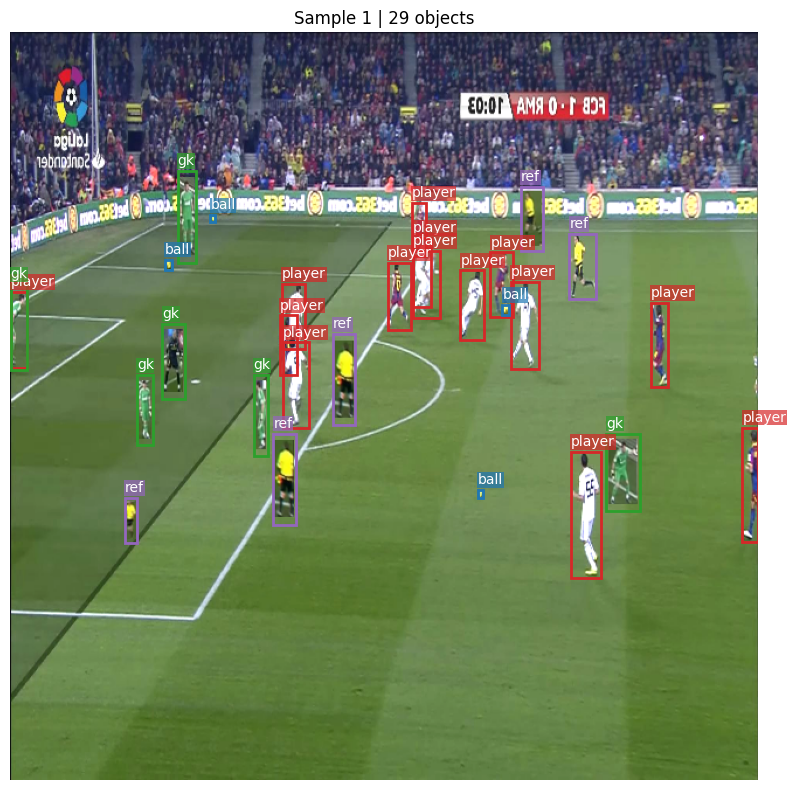

In [13]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import numpy as np
import torch

def visualize_sample(dataset, idx=0, class_names=None):
    img, targets = dataset[idx]  # torch.Tensor
    
    # 1. Приведём изображение к [H, W, C], [0, 255], uint8 для визуализации
    if isinstance(img, torch.Tensor):
        img = img.permute(1, 2, 0).cpu().numpy()  # [H, W, C]
    # img сейчас в [0,1] → переводим в [0,255]
    img_vis = (img * 255).astype(np.uint8)

    # 2. targets: [N, 5] = [cls, x, y, w, h] — нормализованные
    if isinstance(targets, torch.Tensor):
        targets = targets.cpu().numpy()
    
    H, W = img_vis.shape[:2]
    
    # 3. Визуализация
    fig, ax = plt.subplots(1, figsize=(12, 8))
    ax.imshow(img_vis)
    ax.axis('off')
    
    # Цвета для классов
    colors = plt.cm.tab10(np.linspace(0, 1, 10))
    
    for target in targets:
        if len(target) == 0:
            continue
        cls_id, x, y, w, h = target
        
        # Денормализуем bbox
        cx, cy = x * W, y * H
        bw, bh = w * W, h * H
        x1 = cx - bw / 2
        y1 = cy - bh / 2
        
        # Выбираем цвет по cls_id
        color = colors[int(cls_id) % len(colors)]
        
        # Рисуем прямоугольник
        rect = Rectangle(
            (x1, y1), bw, bh,
            linewidth=2, edgecolor=color, facecolor='none'
        )
        ax.add_patch(rect)
        
        # Подпись
        label = class_names[int(cls_id)] if class_names else f"cls{int(cls_id)}"
        ax.text(
            x1, y1 - 5, label,
            color='white', fontsize=10,
            bbox=dict(facecolor=color, alpha=0.7, edgecolor='none', pad=0.5)
        )
    
    plt.title(f"Sample {idx} | {len(targets)} objects")
    plt.tight_layout()
    plt.show()
    return fig

# Используем:
class_names = {0: 'ball', 1: 'coach', 2: 'gk', 3: 'player', 4: 'ref'}
res = visualize_sample(train_dataset, idx=1, class_names=class_names)

In [6]:
from detection_loss import detection_loss
from yolo_model import create_yolo_model
import math

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# device = "cpu"
print("Device:", device)

version = 6
imgsz = 640
batch_size = 16
num_epochs = 100
num_classes = 5  # ball, coach, goalkeeper, player, referee

model = create_yolo_model(num_classes, imgsz=640)
model.to(device)

train_dataset = YOLODataset(GENERAL_PATH + "images/train", GENERAL_PATH + "labels/train", GENERAL_PATH + "train_patches",imgsz=imgsz)
val_dataset = YOLODataset(GENERAL_PATH + "images/val", GENERAL_PATH + "labels/val", GENERAL_PATH + "train_patches", imgsz=imgsz, augment=False)

# collate_fn для списка targets
def collate_fn(batch):
    images, targets = zip(*batch)
    images = torch.stack(images, 0)
    return images, list(targets)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
                            num_workers=0, pin_memory=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False,
                        num_workers=0, pin_memory=True, collate_fn=collate_fn)

# 0.01 обычно для бОльших батчей
optimizer = optim.SGD(model.parameters(), lr=0.005, momentum=0.937, weight_decay=0.0005, nesterov=True)
scaler = torch.amp.GradScaler()

# разогрев для первых эпох, чтобы градиенты не улетали, далее плавное сниэение через cos^2
def lr_lambda(epoch):
    if epoch < 3:
        return (epoch + 1) / 3
    return 0.5 * (1 + math.cos(math.pi * (epoch - 3) / (num_epochs - 3)))

scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

min_val_loss = 0
for epoch in range(num_epochs):
    train_loss, train_logs = train_one_epoch(model, train_loader, optimizer, scaler, detection_loss, device, epoch, imgsz)
    val_loss, val_logs = validate_one_epoch(model, val_loader, detection_loss, device, imgsz)
    scheduler.step()

    # Обновлённый tqdm-статус с валидацией
    tqdm.write(
        f"Epoch {epoch} | "
        f"Train: loss={train_loss:.4f} (box={train_logs['loss_box']:.4f}, obj={train_logs['loss_obj']:.4f}, cls={train_logs['loss_cls']:.4f}) | "
        f"Val: loss={val_loss:.4f} (box={val_logs['loss_box']:.4f}, obj={val_logs['loss_obj']:.4f}, cls={val_logs['loss_cls']:.4f}) | "
        f"pos: {train_logs['num_pos']}/{val_logs['num_pos']}"
    )

    # Сохранение
    if val_loss < min_val_loss or epoch == 0:
        min_val_loss = val_loss
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
        },  WEIGHTS_PATH + f"yolo_best_val_v{version}.pt")

model.eval()
model.apply(lambda m: hasattr(m, 'reparameterize') and m.reparameterize())
torch.save(model.state_dict(), WEIGHTS_PATH + f"yolo_final_rep_v{version}.pt")
print("✅ Model reparameterized and saved for inference!")

Device: cuda
Собрано 2062 редких патчей: {0: 591, 1: 164, 2: 219, 4: 1088}


Epoch 0: 100%|██████████| 40/40 [00:37<00:00,  1.08it/s, loss=3.9193, obj=0.0314, cls=0.7521, box=0.4682, pos=3454]


Epoch 0 | Train: loss=4.2024 (box=0.4949, obj=0.0367, cls=0.9086) | Val: loss=4.0480 (box=0.4816, obj=0.0359, cls=0.8003) | pos: 3565.45/2714.7


Epoch 1: 100%|██████████| 40/40 [00:38<00:00,  1.05it/s, loss=3.3895, obj=0.0174, cls=0.3558, box=0.4259, pos=3405]


Epoch 1 | Train: loss=3.5540 (box=0.4389, obj=0.0230, cls=0.4780) | Val: loss=3.3161 (box=0.4111, obj=0.0193, cls=0.4265) | pos: 3582.025/2725.7


...

Epoch 97 | Train: loss=1.6822 (box=0.2215, obj=0.0026, cls=0.0374) | Val: loss=1.6733 (box=0.2172, obj=0.0020, cls=0.0844) | pos: 3919.1/2819.6


Epoch 98: 100%|██████████| 40/40 [00:53<00:00,  1.33s/it, loss=1.6984, obj=0.0026, cls=0.0169, box=0.2250, pos=3960]


Epoch 98 | Train: loss=1.6856 (box=0.2221, obj=0.0026, cls=0.0347) | Val: loss=1.6726 (box=0.2172, obj=0.0020, cls=0.0833) | pos: 4022.175/2819.3


Epoch 99: 100%|██████████| 40/40 [00:53<00:00,  1.33s/it, loss=1.6125, obj=0.0026, cls=0.0248, box=0.2130, pos=4009]


Epoch 99 | Train: loss=1.6797 (box=0.2215, obj=0.0026, cls=0.0325) | Val: loss=1.6738 (box=0.2173, obj=0.0020, cls=0.0844) | pos: 3971.825/2819.0
✅ Model reparameterized and saved for inference!


In [6]:
import torch
import numpy as np
from PIL import Image, ImageDraw, ImageFont
from torchvision import transforms
from torchvision.ops import nms, box_convert


def predict_and_visualize_v2(
    model,
    image,
    class_names,
    device='cuda',
    imgsz=640,
    conf_thres=0.5,
    iou_thres=0.45,
    max_dets=300
):
    """
    Predict and visualize with simple resize (no letterbox), PIL-based loading.
    
    Args:
        model: trained model → [B, N, 9]
        image: str (path) or PIL.Image
        class_names: list or dict, e.g. ['ball', 'player', ...]
        device: 'cuda' or 'cpu'
        imgsz: resize to (imgsz, imgsz) — no letterbox
        conf_thres: obj × cls confidence threshold
        iou_thres: NMS IoU threshold
        max_dets: max detections after NMS
    
    Returns:
        PIL.Image with boxes and labels
    """
    model.eval()
    
    # 1. Загрузка и препроцессинг через PIL + transforms
    if isinstance(image, str):
        pil_img_orig = Image.open(image).convert("RGB")
    elif isinstance(image, Image.Image):
        pil_img_orig = image.convert("RGB")
    else:
        raise TypeError("image must be str or PIL.Image")
    
    # Transform: resize → tensor → normalize
    transform = transforms.Compose([
        transforms.Resize((imgsz, imgsz)),
        transforms.ToTensor(),
    ])
    x = transform(pil_img_orig).unsqueeze(0).to(device)  # [1, 3, 640, 640]

    # 2. Inference
    with torch.no_grad(), torch.amp.autocast(device):
        pred = model(x)  # [1, N, 9]

    # 3. Декодирование предиктов
    pred = pred[0]  # [N, 9]
    box_cxcywh = pred[:, :4]          # [N, 4]
    obj_logit = pred[:, 4]            # [N]
    cls_logits = pred[:, 5:]          # [N, C]
    
    obj_conf = obj_logit.sigmoid()
    cls_conf = cls_logits.sigmoid()
    class_conf, class_id = cls_conf.max(dim=1)
    conf = obj_conf * class_conf

    # 4. Фильтрация по confidence
    keep = conf > conf_thres
    if keep.sum() == 0:
        return pil_img_orig.copy()

    box_cxcywh = box_cxcywh[keep]
    conf = conf[keep]
    class_id = class_id[keep]

    # 5. Конвертация в xyxy (в координатах 640×640)
    box_xyxy = box_convert(box_cxcywh, in_fmt='cxcywh', out_fmt='xyxy')

    # 6. ⭐ Class-Separated NMS (важно!)
    # Группируем по классам и делаем NMS внутри каждого класса
    keep_nms = []
    for cls in torch.unique(class_id):
        cls_mask = class_id == cls
        cls_boxes = box_xyxy[cls_mask]
        cls_conf = conf[cls_mask]
        cls_keep = nms(cls_boxes, cls_conf, iou_threshold=iou_thres)
        keep_nms.append(torch.where(cls_mask)[0][cls_keep])
    if keep_nms:
        keep_nms = torch.cat(keep_nms)
        keep_nms = keep_nms[conf[keep_nms].argsort(descending=True)[:max_dets]]  # top-k by confidence runs\weights\yolo_final_rep_v5.pt
    else:
        keep_nms = torch.tensor([], dtype=torch.long)
    if len(keep_nms) == 0:
        return pil_img_orig.copy()
    box_xyxy = box_xyxy[keep_nms]
    conf = conf[keep_nms]
    class_id = class_id[keep_nms]

    # cls_boxes = box_xyxy
    # cls_conf = conf
    # cls_keep = nms(cls_boxes, cls_conf, iou_threshold=iou_thres)
    # cls_keep = cls_keep[:max_dets]

    # box_xyxy = box_xyxy[cls_keep]
    # conf = conf[cls_keep]
    # class_id = class_id[cls_keep]

    # # 7. Масштабирование bbox'ов обратно в оригинальное изображение (640→orig)
    orig_w, orig_h = pil_img_orig.size
    # box_xyxy сейчас в [0, 640], нужно в [0, orig_w] × [0, orig_h]
    box_xyxy[:, [0, 2]] *= orig_w / imgsz
    box_xyxy[:, [1, 3]] *= orig_h / imgsz

    # Округление до целых
    box_xyxy = box_xyxy.round().int()

    # 8. Отрисовка
    result_img = pil_img_orig.copy()
    draw = ImageDraw.Draw(result_img)

    try:
        font = ImageFont.truetype("DejaVuSans.ttf", size=16)
    except:
        font = ImageFont.load_default()

    colors = [
        (255, 0, 0), (0, 255, 0), (0, 0, 255), (255, 255, 0), (0, 255, 255),
        (255, 0, 255), (128, 0, 0), (0, 128, 0), (0, 0, 128), (128, 128, 0)
    ]

    for i in range(len(box_xyxy)):
        x1, y1, x2, y2 = box_xyxy[i].tolist()
        cls = int(class_id[i].item())
        prob = conf[i].item()
        
        label = f"{class_names[cls]} {prob:.2f}"
        color = colors[cls % len(colors)]
        
        # 1. Рисуем bbox
        draw.rectangle([x1, y1, x2, y2], outline=color, width=3)  # ширина 3 → лучше видно
        
        # 2. Подпись — НАД bbox'ом, на контрастной подложке
        # Определяем позицию подписи: сверху-слева от bbox
        text_x = x1
        text_y = max(y1 - 25, 0)  # не вылезаем за верх
        
        # Размер подписи
        try:
            font = ImageFont.truetype("Arial.ttf", 40)
        except:
            try:
                font = ImageFont.truetype("DejaVuSans-Bold.ttf", 40)
            except:
                font = ImageFont.load_default(20)
        
        # Белый жирный текст
        draw.text((text_x, text_y), label, fill=(255, 255, 255), font=font, stroke_width=1, stroke_fill=(0, 0, 0))


    return result_img

In [8]:
from yolo_model import create_yolo_model
import torch
device = 'cuda'
# ИЗМЕНИТЬ ДЛЯ ИСПОЛЬЗОВАНИЯ
PROJECT_PATH =  "D:/model_descriptor/ML_MAGA/project/"
GENERAL_PATH = PROJECT_PATH + "coco_yolo/"
TEST_PATH =    PROJECT_PATH + "dataset/test/"
WEIGHTS_PATH = PROJECT_PATH + "model/runs/weights/"

model = create_yolo_model().to(device).eval()
model.apply(lambda m: hasattr(m, 'reparameterize') and m.reparameterize())
class_names = ['ball', 'coach', 'goalkeeper', 'player', 'referee']  # или dict
model.load_state_dict(torch.load(WEIGHTS_PATH + 'yolo_final_rep_v6.pt'))

# Тест на изображении
img_path = TEST_PATH + "frame_22959_png.rf.328de5f62c69429926b33e5d1b1761a2.jpg"
result_img = predict_and_visualize_v2(
    model, img_path, class_names,
    device='cuda',
    imgsz=640,
    conf_thres=0.3,   # можно снизить для мелких объектов (мяч!)
    iou_thres=0.1
)

# Показать
result_img.show()

In [2]:
from yolo_model import create_yolo_model
device = 'cuda'
model = create_yolo_model().to(device).eval()
model.apply(lambda m: hasattr(m, 'reparameterize') and m.reparameterize())
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Количество параметров модели:", num_params)

Количество параметров модели: 14920584


На cuda - 22.5 фпс, на cpu - 5